In [1]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

100%|██████████| 242M/242M [00:02<00:00, 123MB/s]

Extracting files...


In [2]:
path

'/root/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2'

In [3]:
import pandas as pd
df = pd.read_csv("/content/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:

# Give reviews with Score>3 a positive rating, and reviews with a score<3 a negative rating.
def partition(x):
    if x < 3:
        return 'negative'
    return 'positive'


actualScore = df['Score']
positiveNegative = actualScore.map(partition)
df['Senti_Score'] = positiveNegative

In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Senti_Score
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive


In [6]:
df.shape

(568454, 11)

In [7]:
#Sorting data according to ProductId in ascending order
sorted_data=df.sort_values('ProductId', axis=0, ascending=True, inplace=False, kind='quicksort', na_position='last')

In [8]:
#Deduplication of entries
final=sorted_data.drop_duplicates(subset={"UserId","ProfileName","Time","Text"}, keep='first', inplace=False)
final.shape

(393933, 11)

In [9]:
#Checking to see how much % of data still remains
(final['Id'].size*1.0)/(df['Id'].size*1.0)*100

69.29901100176971

In [10]:
final['Senti_Score'].value_counts()

,count
Senti_Score,
positive,336826
negative,57107


In [11]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
tf_idf_vect = TfidfVectorizer(ngram_range=(1,2))
final_tf_idf = tf_idf_vect.fit_transform(final['Text'].values)

In [13]:
final_tf_idf.shape

(393933, 3086802)

In [14]:
final['Senti_Score'].shape

(393933,)

In [16]:
tf_idf_vect.vocabulary_

{'in': 1343370,
 'june': 1449286,
 'br': 403141,
 'saw': 2312330,
 'charming': 540187,
 'group': 1198856,
 'of': 1836847,
 'roses': 2273841,
 'all': 108028,
 'begin': 327695,
 'to': 2765972,
 'droop': 850151,
 'pepped': 2003107,
 'them': 2701294,
 'up': 2869200,
 'with': 3016891,
 'chicken': 556274,
 'soup': 2472265,
 'sprinkle': 2498508,
 'once': 1880048,
 'twice': 2837858,
 'rice': 2253951,
 'this': 2731979,
 'is': 1397236,
 'great': 1183310,
 'book': 383909,
 'teach': 2632623,
 'children': 559766,
 'the': 2666360,
 'months': 1705945,
 'year': 3058075,
 'repetition': 2231221,
 'phrases': 2022375,
 'and': 148454,
 'funny': 1110641,
 'little': 1552731,
 'stories': 2540340,
 'accompanying': 62429,
 'pictures': 2026055,
 'make': 1602569,
 'for': 1053084,
 'an': 143954,
 'ideal': 1329271,
 'bedtime': 318621,
 'read': 2184416,
 'isn': 1410170,
 'nearly': 1761927,
 'as': 217052,
 'good': 1158649,
 'some': 2453447,
 'sendak': 2348049,
 'other': 1925096,
 'books': 384459,
 'like': 1530154,
 '

In [23]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
vectorizer = TextVectorization(
    max_tokens=1000,
    output_mode="int",
    output_sequence_length=100
)

In [24]:
vectorizer.adapt(final['Text'])

vectorized_text = vectorizer(final['Text'])
print(vectorized_text)

tf.Tensor(
[[ 11   1   3 ...   0   0   0]
 [ 10   9   5 ...   0   0   0]
 [  3   1  66 ...   0   0   0]
 ...
 [  3 118  10 ...   0   0   0]
 [275  10  41 ...   0   0   0]
 [  3 275  10 ...   0   0   0]], shape=(393933, 100), dtype=int64)


In [21]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(vectorized_text.numpy(), final['Senti_Score'], test_size=0.2)

In [33]:
X_train.dtype

dtype('int64')

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Input, GRU, LSTM

In [47]:
modelRNN = Sequential([
    Input(shape=(100,)),
    Embedding(1000, 32),
    SimpleRNN(5, return_sequences=True),
    SimpleRNN(5),
    Dense(1, activation='sigmoid')
])

In [48]:
modelRNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,251 (125.98 KB)

 Trainable params: 32,251 (125.98 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
modelRNN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [50]:
y_train_encoded = y_train.map({'positive': 1, 'negative': 0})
y_test_encoded = y_test.map({'positive': 1, 'negative': 0})
history1 = modelRNN.fit(x=X_train, y=y_train_encoded, epochs=10, batch_size=1000, validation_split=0.3)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.8293 - loss: 0.4635 - val_accuracy: 0.8550 - val_loss: 0.4138
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8554 - loss: 0.4125 - val_accuracy: 0.8550 - val_loss: 0.4132
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8551 - loss: 0.4122 - val_accuracy: 0.8550 - val_loss: 0.4125
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8555 - loss: 0.4095 - val_accuracy: 0.8550 - val_loss: 0.4116
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8570 - loss: 0.4049 - val_accuracy: 0.8523 - val_loss: 0.4113
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8576 - loss: 0.4017 - val_accuracy: 0.8548 - val_loss: 0.4092
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8575 - loss: 0.4005 - val_accuracy: 0.8543 - val_loss: 0.4105
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8575 - loss: 0.3992 - val_ac

In [54]:
modelLSTM = Sequential([
    Input(shape=(100,)),
    Embedding(1000, 32),
    LSTM(5, return_sequences=True),
    LSTM(5),
    Dense(1, activation='sigmoid')
])

In [55]:
modelLSTM.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
history2 = modelLSTM.fit(x=X_train, y=y_train_encoded, epochs=10, batch_size=1000, validation_split=0.3)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8388 - loss: 0.4840 - val_accuracy: 0.8550 - val_loss: 0.4135
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8571 - loss: 0.4094 - val_accuracy: 0.8550 - val_loss: 0.4107
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8571 - loss: 0.3807 - val_accuracy: 0.8776 - val_loss: 0.2965
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8792 - loss: 0.2913 - val_accuracy: 0.8886 - val_loss: 0.2717
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8928 - loss: 0.2641 - val_accuracy: 0.8943 - val_loss: 0.2579
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8974 - loss: 0.2510 - val_accuracy: 0.8942 - val_loss: 0.2518
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9002 - loss: 0.2430 - val_accuracy: 0.8970 - val_loss: 0.2465
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9021 - loss: 0.2371 - val_accu

In [57]:
modelGRU = Sequential([
    Input(shape=(100,)),
    Embedding(1000, 32),
    GRU(5, return_sequences=True),
    GRU(5),
    Dense(1, activation='sigmoid')
])


In [58]:
modelGRU.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [59]:
history3 = modelGRU.fit(x=X_train, y=y_train_encoded, epochs=10, batch_size=1000, validation_split=0.3)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8526 - loss: 0.4692 - val_accuracy: 0.8550 - val_loss: 0.4134
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8565 - loss: 0.4045 - val_accuracy: 0.8844 - val_loss: 0.2805
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8917 - loss: 0.2644 - val_accuracy: 0.8972 - val_loss: 0.2481
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9012 - loss: 0.2412 - val_accuracy: 0.9007 - val_loss: 0.2373
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9059 - loss: 0.2278 - val_accuracy: 0.9038 - val_loss: 0.2293
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9091 - loss: 0.2187 - val_accuracy: 0.9047 - val_loss: 0.2261
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9117 - loss: 0.2118 - val_accuracy: 0.9071 - val_loss: 0.2210
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9134 - loss: 0.2075 - val_accu

In [60]:
import matplotlib.pyplot as plt

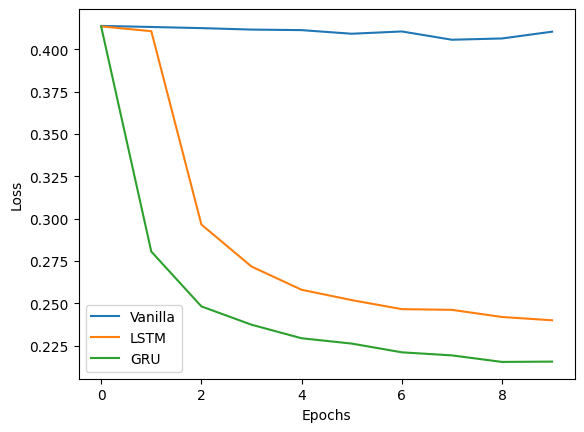

In [61]:
plt.plot(history1.history['val_loss'],label='Vanilla')
plt.plot(history2.history['val_loss'],label='LSTM')
plt.plot(history3.history['val_loss'],label='GRU')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()